# Recherche stratégie — copier les trades du Congrès (2014-2026)

**La question** : les transactions déclarées par les élus américains contiennent-elles un signal qu'un
investisseur extérieur peut copier — sachant qu'il ne les voit qu'à leur **publication** (0-45 jours
après le trade) ?

**La démarche, dans l'ordre où on se pose les questions :**
1. **Les données** — la table canonique certifiée + les prix. On regarde d'abord à quoi ressemble un trade.
2. **La mesure de base** — l'excès de rendement d'un trade, calculé à la main sur un exemple, puis généralisé.
3. **L'événement** — y a-t-il de l'info après la *transaction* (plafond théorique) ? après la *publication* (jouable) ?
4. **La stratégie du brief Ramify** — copy-trading trade-based avec sélection annuelle top-K. Chaque
   paramètre justifié par ce qu'on aura vu aux étapes précédentes.
5. **Deux variantes** issues de l'état de l'art (leaders de parti, horizon court).
6. **V2 ETF sectoriels** — l'univers d'investissement de Ramify.
7. **Du trade au portefeuille** — les mêmes trades vus en **compte** : NAV quotidienne, coûts sur le
   turnover, Sharpe/maxDD comparés au même argent dans SPY.
8. **Le verdict**, situé dans la littérature.

**Conventions (tout le notebook)** : entrée au premier jour de bourse **après** l'événement (J+1, aucun
look-ahead) · coûts **c = 20 bps** par transaction (40 bps l'aller-retour) · chaque trade = **une
observation** (§2-6 ; le §7 passe au compte) · excès mesuré **vs SPY** sur la même fenêtre.

## 1. Les données

- **Transactions** : `transactions_backtest_2014_2026.csv` — la table certifiée par l'audit données
  (100 % de l'index officiel House traité, identité/parti/commissions à la date du trade,
  `amount_midpoint` = milieu exact de fourchette, `ticker_yahoo` prêt pour les prix).
- On commence par regarder **trois lignes concrètes** : c'est ça, un trade.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

HERE = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd() / "00. S3S4 en cours"
REPO = HERE.parent
CLEAN = REPO / "00_S1S2_donnees" / "data" / "clean" / "transactions_backtest_2014_2026.csv"
PRICES = HERE / "cache" / "prices_v2"

COST = 20 / 1e4          # c = 20 bps par transaction
HOLD_MAX = 252           # plafond du brief : 12 mois = 252 jours de bourse

df = pd.read_csv(CLEAN, dtype={"doc_id": str}, parse_dates=["transaction_date", "disclosure_date"])
achats, ventes = df[df["direction"] == "buy"], df[df["direction"] == "sell"]
print(f"{len(df):,} transactions | {df['bioguide_id'].nunique()} membres | "
      f"{df['ticker_yahoo'].nunique():,} tickers | achats {len(achats):,} / ventes {len(ventes):,}")
print(f"délai médian transaction → publication : {df['lag_days'].median():.0f} jours\n")
print(df[["member_name", "ticker_yahoo", "direction", "transaction_date", "disclosure_date",
          "amount_midpoint"]].sample(3, random_state=7).to_string(index=False))

134,464 transactions | 372 membres | 4,618 tickers | achats 68,250 / ventes 66,214
délai médian transaction → publication : 27 jours

 member_name ticker_yahoo direction transaction_date disclosure_date  amount_midpoint
Rohit Khanna          ACN      sell       2017-04-03      2017-05-11           8000.5
 Bill Flores           CL       buy       2014-02-05      2014-03-12           8000.5
Rohit Khanna           DG       buy       2021-08-24      2021-09-15          32500.5


- **Prix** : cache `cache/prices_v2/` construit sur `ticker_yahoo` (yfinance ajusté dividendes/splits,
  2012→2026) — **par la cellule ci-dessous** : le notebook est auto-suffisant.
  - Symboles : renommages/fusions DÉJÀ appliqués par la table (`data/reference/ticker_renames.csv`).
  - Resumable : un CSV présent n'est jamais re-téléchargé ; **cache complet → 0 appel réseau** (le
    notebook s'exécute hors-ligne).
  - Échecs classés dans `failed_v2.csv` (`delisting_attendu` via le référentiel vs `inattendu`) ;
    jamais de liste noire à vie : `RETRY_FAILED = True` re-tente tout (leçon de l'audit — MMC/DENN/FI
    étaient des échecs Yahoo transitoires bloqués à vie par l'ancien `failed_tickers.txt`).
- Garde-fou anti-corruption au chargement : Yahoo renvoie parfois des séries cassées (prix négatifs,
  sauts ×1000) — toute série avec un prix < 0,10 $ ou un saut quotidien > 300 % est écartée (~0,3 % des
  trades ; filtre évalué sur toute la série = légère exclusion rétroactive, assumée pour la propreté).

In [2]:
# (Re)construction du cache prix — ne télécharge que ce qui manque ; cache complet = 0 réseau.
RETRY_FAILED = False     # True : re-tente aussi les échecs passés (Yahoo a des échecs transitoires)

BENCH = ["SPY", "RSP", "QQQ", "XLE", "XLB", "XLI", "XLY", "XLP", "XLV", "XLF", "XLK", "XLC", "XLU", "XLRE"]
PRICES.mkdir(parents=True, exist_ok=True)
univers = list(dict.fromkeys(sorted(set(df["ticker_yahoo"].dropna()) - {""}) + BENCH))
en_cache = {f.stem for f in PRICES.glob("*.csv") if f.stat().st_size > 200}
fichier_echecs = PRICES / "failed_v2.csv"
echecs_connus = set(pd.read_csv(fichier_echecs)["ticker"]) if fichier_echecs.exists() else set()
a_faire = [tk for tk in univers if tk not in en_cache and (RETRY_FAILED or tk not in echecs_connus)]
print(f"{len(univers)} symboles à couvrir | en cache : {len(en_cache & set(univers))} "
      f"| échecs connus : {len(echecs_connus & set(univers))} | à télécharger : {len(a_faire)}")

if not a_faire:
    print("cache complet — aucun téléchargement (exécution hors-ligne)")
else:
    import logging, time
    import yfinance as yf
    for noisy in ("yfinance", "urllib3", "peewee"):
        logging.getLogger(noisy).setLevel(logging.CRITICAL)
    ren = pd.read_csv(REPO / "00_S1S2_donnees" / "data" / "reference" / "ticker_renames.csv", dtype=str)
    delisted = set(ren.loc[ren["type"].isin(["rachat_delisting", "faillite_delisting"]), "ticker_ancien"])
    ok, fails = 0, []
    for i, tk in enumerate(a_faire, 1):
        got = False
        for attempt in range(3):
            try:
                h = yf.Ticker(tk).history(start="2012-01-01", auto_adjust=True)
                if len(h) >= 30:
                    out = h["Close"].rename("close").reset_index()
                    out["Date"] = pd.to_datetime(out["Date"]).dt.date
                    out.to_csv(PRICES / f"{tk}.csv", index=False)
                    ok += 1; got = True
                break                # série vide/trop courte : délisté chez Yahoo, inutile d'insister
            except Exception:
                time.sleep(1.5 * (attempt + 1))
        if not got:
            fails.append({"ticker": tk, "classe": "delisting_attendu" if tk in delisted else "inattendu"})
        if i % 250 == 0:
            print(f"  {i}/{len(a_faire)} | ok {ok} | échecs {len(fails)}", flush=True)
        time.sleep(0.25)
    # failed_v2.csv mis à jour : on retire les tickers récupérés, on ajoute les nouveaux échecs
    anciens = pd.read_csv(fichier_echecs) if fichier_echecs.exists() else pd.DataFrame(columns=["ticker", "classe"])
    reussis = set(a_faire) - {f["ticker"] for f in fails}
    (pd.concat([anciens[~anciens["ticker"].isin(reussis)], pd.DataFrame(fails)])
       .drop_duplicates("ticker").to_csv(fichier_echecs, index=False))
    n_att = sum(1 for f in fails if f["classe"] == "delisting_attendu")
    print(f"téléchargés : {ok} | échecs : {len(fails)} (dont {n_att} délistages attendus) → failed_v2.csv à jour")

4618 symboles à couvrir | en cache : 3350 | échecs connus : 1268 | à télécharger : 0
cache complet — aucun téléchargement (exécution hors-ligne)


In [3]:
def load_price(tk):
    f = PRICES / f"{tk}.csv"
    if not f.exists() or f.stat().st_size < 200:
        return None
    s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"]
    if s.min() < 0.10 or s.pct_change().abs().max() > 3.0:
        return None
    return s

spy = load_price("SPY")
CAL = spy.index                                   # calendrier de bourse maître
series = {tk: s for tk in sorted(set(df["ticker_yahoo"].dropna())) if (s := load_price(tk)) is not None}
px = pd.DataFrame(series).reindex(CAL)
spy = spy.reindex(CAL)

couverture = df["ticker_yahoo"].isin(px.columns)
print(f"panel prix : {px.shape[1]:,} tickers × {len(CAL):,} jours ({CAL.min().date()} → {CAL.max().date()})")
print(f"trades couverts : {couverture.sum():,} / {len(df):,} ({couverture.mean():.1%}) — non couverts : "
      f"délistés sans successeur et symboles que Yahoo ne sert plus (couverture ~74 % en 2014, ~99 % en 2026)")

panel prix : 3,289 tickers × 3,645 jours (2012-01-03 → 2026-07-02)
trades couverts : 118,061 / 134,464 (87.8%) — non couverts : délistés sans successeur et symboles que Yahoo ne sert plus (couverture ~74 % en 2014, ~99 % en 2026)


## 2. La mesure de base — l'excès de rendement d'un trade

Pour un trade sur le titre $i$, déclenché par un événement daté $d$ (transaction **ou** publication) :

$$x_i(h) \;=\; \underbrace{\frac{P_i(t_e+h)}{P_i(t_e)} - 1}_{\text{rendement du titre}} \;-\; \underbrace{\frac{B(t_e+h)}{B(t_e)} - 1}_{\text{rendement de SPY}}$$

- $t_e$ = **premier jour de bourse strictement après** $d$ (J+1 : on ne peut pas agir le jour même) ;
- $h$ = l'horizon en jours de bourse ; $B$ = SPY (dividendes réinvestis).

Pour juger si la moyenne $\bar x$ d'un paquet de $n$ trades est différente de zéro :

$$t \;=\; \frac{\bar{x}}{s/\sqrt{n}} \qquad (s = \text{écart-type des } x_i)$$

⚠ *Les fenêtres des trades se **chevauchent** (deux achats du même mois vivent le même marché) : les
observations ne sont pas indépendantes, donc ces $t$ sont **optimistes**. On les lit comme des ordres
de grandeur — un $t$ qui n'atteint même pas 2 dans ces conditions favorables est un non-résultat clair.*

**D'abord un exemple à la main** (le réflexe du brief : « Pelosi déclare un achat de NVDA… ») :

In [4]:
# Un vrai trade de la table, calculé pas à pas.
ex = achats[(achats["member_name"].str.contains("Pelosi")) & (achats["ticker_yahoo"] == "NVDA")
            ].sort_values("disclosure_date").iloc[0]
d = ex["disclosure_date"]
t_e = CAL[CAL.searchsorted(d, side="right")]                  # 1er jour de bourse APRÈS la publication
t_h = CAL[CAL.searchsorted(d, side="right") + 63]             # horizon h = 63 j (≈ 3 mois)
p0, p1 = px.loc[t_e, "NVDA"], px.loc[t_h, "NVDA"]
b0, b1 = spy.loc[t_e], spy.loc[t_h]
x = (p1 / p0 - 1) - (b1 / b0 - 1)
print(f"{ex['member_name']} achète NVDA (transaction {ex['transaction_date'].date()}, "
      f"publiée {d.date()})")
print(f"entrée {t_e.date()} @ {p0:.2f} $ → sortie {t_h.date()} @ {p1:.2f} $ : "
      f"titre {(p1/p0-1):+.2%}, SPY {(b1/b0-1):+.2%} → excès x = {x:+.2%}")

Nancy Pelosi achète NVDA (transaction 2021-07-23, publiée 2021-08-20)
entrée 2021-08-23 @ 21.88 $ → sortie 2021-11-19 @ 32.88 $ : titre +50.25%, SPY +5.17% → excès x = +45.07%


In [5]:
# La même chose, vectorisée pour les ~118 000 trades (mêmes formules, indexation numpy).
PXV, SPYV = px.to_numpy(), spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}

def batch_excess(tks, dates, h):
    """x_i(h) pour chaque (ticker, date d'événement) — NaN si prix indisponible ou horizon non écoulé."""
    i0 = CAL.searchsorted(pd.DatetimeIndex(dates), side="right")   # t_e = J+1
    i1 = i0 + h
    cols = np.array([COL.get(t, -1) for t in tks])
    ok = (cols >= 0) & (i1 < len(CAL))
    out = np.full(len(tks), np.nan)
    r, c0, c1 = cols[ok], i0[ok], i1[ok]
    p0, p1 = PXV[c0, r], PXV[c1, r]
    b0, b1 = SPYV[c0], SPYV[c1]
    valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0) & (b0 > 0)
    res = np.full(int(ok.sum()), np.nan)
    res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1)
    out[ok] = res
    return out

# contrôle : la version vectorisée retrouve l'exemple à la main
x_chk = batch_excess(np.array(["NVDA"]), np.array([d]), 63)[0]
print(f"contrôle vectorisé sur l'exemple : {x_chk:+.2%} (identique : {abs(x_chk - x) < 1e-12})")

contrôle vectorisé sur l'exemple : +45.07% (identique : True)


## 3. L'événement — y a-t-il de l'info, et à quelle date ?

- On calcule $\bar x(h)$ pour **tous les achats**, à 5 horizons, depuis les **deux dates** :
  - la **transaction** = ce que savait l'élu → le **plafond théorique** (personne ne peut copier ça) ;
  - la **publication** = ce qu'un copieur peut réellement jouer.
- Si même le plafond est vide, tout l'aval est borné (loi fondamentale de Grinold-Kahn :
  $IR \approx IC \times \sqrt{breadth}$ — sans IC, pas d'IR).

In [6]:
HORIZONS = {"1 sem": 5, "1 mois": 21, "3 mois": 63, "6 mois": 126, "12 mois": 252}

def table_evenement(sub):
    rows = []
    for nom, h in HORIZONS.items():
        for date_col, etiquette in [("transaction_date", "transaction (plafond)"),
                                    ("disclosure_date", "publication (jouable)")]:
            x = batch_excess(sub["ticker_yahoo"].to_numpy(), sub[date_col].to_numpy(), h)
            x = x[~np.isnan(x)]
            t = x.mean() / (x.std() / np.sqrt(len(x))) if len(x) > 1 else np.nan
            rows.append({"horizon": nom, "depuis": etiquette, "n": len(x),
                         "excès moyen": f"{x.mean():+.2%}", "médiane": f"{np.median(x):+.2%}",
                         "% gagnants": f"{(x > 0).mean():.0%}", "t": round(t, 2)})
    return pd.DataFrame(rows)

print("ACHATS — excès vs SPY (entrée J+1)")
print(table_evenement(achats).to_string(index=False))

ACHATS — excès vs SPY (entrée J+1)
horizon                depuis     n excès moyen médiane % gagnants     t
  1 sem transaction (plafond) 58925      -0.01%  -0.06%        49% -0.50
  1 sem publication (jouable) 58902      -0.04%  -0.07%        49% -2.25
 1 mois transaction (plafond) 58881      -0.18%  -0.20%        48% -5.13
 1 mois publication (jouable) 58504      +0.07%  -0.23%        48%  1.89
 3 mois transaction (plafond) 58104      -0.27%  -0.73%        47% -4.15
 3 mois publication (jouable) 57628      -0.36%  -0.75%        47% -5.67
 6 mois transaction (plafond) 56532      -0.76%  -1.70%        45% -7.99
 6 mois publication (jouable) 56244      -0.74%  -1.78%        45% -7.76
12 mois transaction (plafond) 54135      -0.58%  -3.69%        44% -3.62
12 mois publication (jouable) 53109      -0.35%  -3.53%        44% -2.09


In [7]:
print("VENTES — excès vs SPY des titres VENDUS (négatif = la vente était bien avisée)")
print(table_evenement(ventes).to_string(index=False))

VENTES — excès vs SPY des titres VENDUS (négatif = la vente était bien avisée)
horizon                depuis     n excès moyen médiane % gagnants     t
  1 sem transaction (plafond) 57024      +0.03%  -0.03%        49%  1.27
  1 sem publication (jouable) 56973      -0.14%  -0.12%        48% -7.42
 1 mois transaction (plafond) 56968      -0.11%  -0.20%        49% -2.87
 1 mois publication (jouable) 56396      -0.12%  -0.28%        48% -3.00
 3 mois transaction (plafond) 56046      -0.31%  -0.87%        47% -4.18
 3 mois publication (jouable) 55615      -0.43%  -0.94%        47% -6.32
 6 mois transaction (plafond) 54461      -0.66%  -1.89%        45% -6.05
 6 mois publication (jouable) 54168      -0.67%  -1.99%        45% -5.94
12 mois transaction (plafond) 51827      -0.69%  -3.47%        44% -3.48
12 mois publication (jouable) 51121      -0.55%  -3.61%        44% -2.55


### Lecture — la question est tranchée

- **Il n'y a pas d'information moyenne dans les trades, même à la date de transaction** : hormis la
  trace à 1 mois post-publication (bullet suivant), les achats sous-performent SPY à tous les horizons,
  y compris au plafond théorique (−0,76 % à 6 mois, t −8,0 ; −0,58 % à 12 mois). Si le plafond est
  vide, la version jouable ne peut pas faire mieux — et c'est exactement ce que trouve la littérature
  (Belmont 2022 : −26 bps à 6 mois ; Chen & Sacerdote : les élus achètent après le pic d'attention).
- **Une seule trace positive : +0,07 % le mois qui suit la PUBLICATION** (t 1,9) — le « drift
  post-disclosure » documenté par Abdurakhmonov (+12-21 bps) et Lazzaretto. Ordre de grandeur : ~7 bps,
  soit **6× moins que nos coûts** d'aller-retour (40 bps). Réel, mais pas exploitable en moyenne.
- **Les ventes ne disent rien de plus** : les titres vendus sous-performent aussi (−0,55 % à 12 mois),
  du même ordre que les achats → **aucun spread directionnel** (la leçon Ziobrowski-House : quand tout
  ce que touche le Congrès « sous-performe » pareil, c'est du style, pas du signal).
- **Attention au benchmark** : SPY 2014-2026 = les méga-caps ; un panier diversifié non-mégacap
  sous-performe mécaniquement cette référence (Hanousek : le signe peut basculer selon le benchmark).
  Les −0,3/−0,7 % mesurent donc largement un tilt de style.
- La médiane (−3,5 % à 12 mois) très en dessous de la moyenne = **loterie à queue droite** : quelques
  gros gagnants rares portent la moyenne. → **C'est cette queue que la sélection de membres du brief va
  tenter de capter. Section suivante.**

## 4. La stratégie du brief Ramify — copy-trading trade-based

**Les règles du brief, à la lettre :**
- **Entrée** : à la publication d'un « Purchase » d'un membre suivi → position au jour de bourse J+1.
- **Sortie** : à la publication de la première « Sale » du même membre sur ce ticker ; sinon **sortie
  forcée à 12 mois**. On lit ce « 12 mois » comme un **plafond** :

$$t_s \;=\; \min\big(\,t_{\text{vente publiée}},\; t_e + 252\,\big)$$

  *(sans ce plafond, 20 % des trades seraient détenus > 12 mois — jusqu'à 12 ans — et quelques
  positions multi-années à +3 000 % domineraient toutes les moyennes : vérifié.)*
- **Le rendement net d'un trade** (2 transactions → coût $2c$ = 40 bps) :

$$x_i \;=\; \frac{P_i(t_s)}{P_i(t_e)} - \frac{B(t_s)}{B(t_e)} \;-\; 2c$$

**D'abord la mécanique d'appariement, avec des exemples concrets :**

In [8]:
# Pour chaque achat : la PREMIÈRE vente ultérieure du même (membre, ticker), sur les dates de publication.
b = achats[achats["ticker_yahoo"].isin(px.columns)].copy()
s = ventes[["bioguide_id", "ticker_yahoo", "disclosure_date"]].dropna().sort_values("disclosure_date")
b = b.sort_values("disclosure_date").reset_index(drop=True)

paires = pd.merge_asof(
    b[["bioguide_id", "ticker_yahoo", "disclosure_date"]].reset_index(),
    s.rename(columns={"disclosure_date": "sortie_vente"}),
    left_on="disclosure_date", right_on="sortie_vente",
    by=["bioguide_id", "ticker_yahoo"], direction="forward", allow_exact_matches=False)
b["sortie_vente"] = paires.set_index("index")["sortie_vente"]

part_vente = b["sortie_vente"].notna().mean()
tronques = (b["disclosure_date"] > CAL[-1] - pd.Timedelta(days=370)).mean()
print(f"{len(b):,} achats backtestables | une vente du membre arrive ensuite : {part_vente:.0%} "
      f"| sortie = min(vente, +12 mois)")
print(f"(⚠ {tronques:.0%} des achats ont moins de 12 mois d'historique : détention tronquée au {CAL[-1].date()})\n")

# trois cas concrets : sortie par vente / par plafond 12 mois / tronquée
exemples = pd.concat([
    b[b["sortie_vente"].notna() & (b["sortie_vente"] < b["disclosure_date"] + pd.Timedelta(days=200))].head(1),
    b[b["sortie_vente"].isna() & (b["disclosure_date"] < "2020-01-01")].head(1),
    b[b["disclosure_date"] > "2026-01-01"].head(1)])
print(exemples[["member_name", "ticker_yahoo", "disclosure_date", "sortie_vente"]].to_string(index=False))

59,998 achats backtestables | une vente du membre arrive ensuite : 80% | sortie = min(vente, +12 mois)
(⚠ 10% des achats ont moins de 12 mois d'historique : détention tronquée au 2026-07-02)

  member_name ticker_yahoo disclosure_date sortie_vente
  Bill Flores          NML      2014-01-07   2014-03-12
    Bob Gibbs          TKR      2014-01-03          NaT
Lloyd Doggett          IBM      2026-01-02          NaT


In [9]:
# Le rendement net x_i de chaque trade (formule ci-dessus, vectorisée).
PXF = px.ffill().to_numpy()   # délistés en cours de détention : dernier prix connu (limite assumée)

def trade_excess_net(tks, d_in, d_out):
    i0 = CAL.searchsorted(pd.DatetimeIndex(d_in), side="right")
    i_vente = CAL.searchsorted(pd.DatetimeIndex(pd.Series(d_out).fillna(CAL[-1])), side="right")
    i1 = np.where(pd.isna(d_out), i0 + HOLD_MAX, np.minimum(i_vente, i0 + HOLD_MAX))  # t_s = min(vente, +252 j)
    i1 = np.minimum(np.maximum(i1, i0 + 1), len(CAL) - 1)
    cols = np.array([COL.get(t, -1) for t in tks])
    ok = (cols >= 0) & (i0 < len(CAL) - 1)
    out = np.full(len(tks), np.nan)
    r, c0, c1 = cols[ok], i0[ok], np.asarray(i1)[ok]
    p0, p1 = PXV[c0, r], PXF[c1, r]
    b0, b1 = SPYV[c0], SPYV[c1]
    valid = ~(np.isnan(p0) | np.isnan(p1)) & (p0 > 0)
    res = np.full(int(ok.sum()), np.nan)
    res[valid] = (p1[valid] / p0[valid] - 1) - (b1[valid] / b0[valid] - 1) - 2 * COST
    out[ok] = res
    return out, i1

b["exces_net"], b["_i_sortie"] = trade_excess_net(
    b["ticker_yahoo"].to_numpy(), b["disclosure_date"].to_numpy(), b["sortie_vente"].to_numpy())
b["date_sortie"] = CAL[np.minimum(b["_i_sortie"], len(CAL) - 1)]
bt = b.dropna(subset=["exces_net"]).copy()
print(f"{len(bt):,} trades avec rendement net calculable")
print(f"excès net moyen {bt['exces_net'].mean():+.2%} | médiane {bt['exces_net'].median():+.2%} "
      f"| % gagnants {(bt['exces_net'] > 0).mean():.0%}")
print("\n→ copier TOUT le monde perd (les coûts + la sous-performance moyenne vue au §3).")
print("  Le brief propose donc de SÉLECTIONNER les membres. Sur quel critère ? Suite ↓")

58,910 trades avec rendement net calculable
excès net moyen -0.42% | médiane -1.99% | % gagnants 43%

→ copier TOUT le monde perd (les coûts + la sous-performance moyenne vue au §3).
  Le brief propose donc de SÉLECTIONNER les membres. Sur quel critère ? Suite ↓


### Le track record d'un membre — le critère de sélection du brief

Pour un membre $m$ ayant réalisé $n_m$ trades clôturés d'excès $x_1, \dots, x_{n_m}$ :

$$S_m \;=\; \frac{\bar{x}_m}{\sigma_m} \qquad \text{(le « Sharpe de la série de trades »)}$$

- Pourquoi ce critère (argument du brief) : le *hit rate* ignore la magnitude, le *rendement moyen* est
  esclave des outliers ; $S_m$ **normalise par la régularité** — comparable entre membres qui tradent
  peu ou beaucoup.
- Regardons la dispersion des $S_m$ en plein-échantillon (pour voir le paysage — la sélection honnête,
  sans regarder le futur, arrive juste après) :

In [10]:
tr = (bt.groupby(["bioguide_id", "member_name"])["exces_net"]
        .agg(n="count", exces_moyen="mean", ecart_type="std")
        .query("n >= 10").reset_index())
tr["sharpe_trades"] = tr["exces_moyen"] / tr["ecart_type"]
tr = tr.sort_values("sharpe_trades", ascending=False)
print(f"{len(tr)} membres éligibles (≥ 10 trades clôturés, 2014-2026) — le top 10 :")
print(tr.head(10)[["member_name", "n", "exces_moyen", "sharpe_trades"]]
      .assign(exces_moyen=lambda d: d["exces_moyen"].map("{:+.2%}".format),
              sharpe_trades=lambda d: d["sharpe_trades"].round(2)).to_string(index=False))
print("\n→ une poignée de très beaux track records… vus APRÈS COUP. La vraie question (Mauboussin,")
print("  skill vs luck) : pouvait-on les repérer À L'AVANCE ? C'est le test walk-forward ↓")

196 membres éligibles (≥ 10 trades clôturés, 2014-2026) — le top 10 :
          member_name   n exces_moyen  sharpe_trades
              Ed Case  10      +8.01%           3.41
    Daniel S Sullivan  35     +45.69%           0.67
   Trey Hollingsworth  16      +7.87%           0.59
         Ashley Moody  16     +52.90%           0.55
    Frank A. LoBiondo  18      +8.40%           0.49
         Justin Amash  18     +10.61%           0.46
            Dave Camp 213      +9.82%           0.46
Kelly Louise Morrison  10     +21.98%           0.45
       Kelly Loeffler  42     +11.66%           0.44
 David Cheston Rouzer  13     +30.03%           0.41

→ une poignée de très beaux track records… vus APRÈS COUP. La vraie question (Mauboussin,
  skill vs luck) : pouvait-on les repérer À L'AVANCE ? C'est le test walk-forward ↓


### La sélection annuelle, sans tricher (walk-forward)

Le protocole, année par année :
1. **Au 31/12 de l'année $Y$** : pour chaque membre, on calcule $S_m$ sur ses trades **clôturés avant
   cette date** (aucune information future) ;
2. Éligibles : $n_m \ge 10$ trades clôturés **et** membre encore actif (≥ 1 publication dans l'année
   $Y$ — sinon on « suivrait » des élus qui ont quitté le Congrès) ;
3. On retient les **K meilleurs** $S_m$ (K ∈ {4, 6, 8, 10}) ; option du brief : forcer **≥ K/2** membres
   de commissions clés (Finance/Défense/Renseignement) ;
4. On copie leurs **achats publiés pendant l'année $Y{+}1$** (règles d'entrée/sortie du §4) et on note
   l'excès net moyen de l'année. 8 configurations = **8 essais** — à garder en tête en lisant les $t$.

In [11]:
def membre_cle(annee):
    fen = bt[bt["disclosure_date"].dt.year == annee]
    return fen.groupby("bioguide_id")["committees_key_flag"].agg(
        lambda s: s.astype(str).str.lower().eq("true").mean() >= 0.5)

def selection(annee, K, filtre_commission):
    histo = bt[bt["date_sortie"] <= pd.Timestamp(f"{annee}-12-31")]
    g = histo.groupby("bioguide_id")["exces_net"].agg(n="count", m="mean", sd="std")
    actifs = set(b.loc[b["disclosure_date"].dt.year == annee, "bioguide_id"])
    g = g[(g["n"] >= 10) & (g["sd"] > 0) & g.index.isin(actifs)]
    g["sharpe"] = g["m"] / g["sd"]
    classement = g.sort_values("sharpe", ascending=False).index.tolist()
    if not filtre_commission:
        return classement[:K]
    cle = membre_cle(annee)
    pick, n_cle = [], 0
    for bio in classement:
        if len(pick) == K:
            break
        pick.append(bio); n_cle += bool(cle.get(bio, False))
    if n_cle < K / 2:
        reserves = [x for x in classement if x not in pick and cle.get(x, False)]
        for i in range(len(pick) - 1, -1, -1):
            if n_cle >= K / 2 or not reserves:
                break
            if not cle.get(pick[i], False):
                pick[i] = reserves.pop(0); n_cle += 1
    return pick

In [12]:
ANNEES = range(2015, 2027)
resultats = []
for K in (4, 6, 8, 10):
    for filtre in (False, True):
        exces_annuels, n_trades = [], []
        for annee in ANNEES:
            suivis = selection(annee - 1, K, filtre)
            t_an = bt[(bt["disclosure_date"].dt.year == annee) & bt["bioguide_id"].isin(suivis)]
            exces_annuels.append(t_an["exces_net"].mean() if len(t_an) else 0.0)   # année vide = 0, comptée
            n_trades.append(len(t_an))
        x = pd.Series(exces_annuels)
        resultats.append({"K": K, "filtre commissions": "oui" if filtre else "non",
                          "années": len(x), "dont vides": int((pd.Series(n_trades) == 0).sum()),
                          "n/an méd.": int(pd.Series(n_trades).median()),
                          "excès/trade moyen": f"{x.mean():+.2%}",
                          "écart-type": f"{x.std():.2%}", "années > 0": f"{(x > 0).mean():.0%}",
                          "t": round(x.mean() / (x.std() / np.sqrt(len(x))), 2) if len(x) > 1 else np.nan})
grille = pd.DataFrame(resultats)
print("STRATÉGIE DU BRIEF — walk-forward, net de coûts (8 configurations essayées)")
print(grille.to_string(index=False))

STRATÉGIE DU BRIEF — walk-forward, net de coûts (8 configurations essayées)
 K filtre commissions  années  dont vides  n/an méd. excès/trade moyen écart-type années > 0    t
 4                non      12           0         79            +3.11%      8.27%        67% 1.30
 4                oui      12           0         68            +3.62%      9.86%        58% 1.27
 6                non      12           0        100            +1.97%      8.63%        42% 0.79
 6                oui      12           0         86            +0.67%      8.17%        33% 0.28
 8                non      12           0        200            +3.40%      9.95%        42% 1.18
 8                oui      12           0        166            +2.63%      9.85%        33% 0.93
10                non      12           0        290            +1.01%      4.00%        58% 0.88
10                oui      12           0        290            +1.01%      3.97%        58% 0.88


### Lecture V1 — sans les artefacts, il ne reste rien

- Le copy-trading brut de TOUS les achats **perd** : −0,42 % net par trade (médiane −1,99 %, 43 % de
  gagnants).
- La grille top-K : excès de **+0,7 % à +3,6 % par trade** selon la configuration, mais **t ≤ 1,3
  partout** (8 essais) — indiscernable du hasard de sélection.
- Point de méthode instructif : une première version de ce calcul affichait des t jusqu'à 2,5. Ils
  venaient de trois artefacts — détentions multi-années non plafonnées (un NVDA gardé 8 ans à +3 500 %
  comptait comme UNE observation), membres sélectionnés après leur départ du Congrès, années sans trade
  silencieusement omises. **Chaque correction a fait baisser le t** : le « signal » était de la
  mécanique de backtest, pas du marché.
- Conclusion identique au backtest de la même stratégie sur l'ancienne donnée (t max 0,88) et au
  consensus académique : **la sélection par track record ne produit pas d'alpha démontrable.**
- → **Le track record moyen ne marche pas. Reste deux conditionnements documentés par la littérature ↓**

## 5. Deux variantes issues de l'état de l'art

**(a) Les 12 leaders de parti** — Wei & Zhou (NBER w34524) : l'alpha serait concentré sur les 12 postes
de leadership de PARTI (Speaker, floor leaders, whips, conference chairs — pas les chairs de
commissions) et **persisterait aux dates de publication** (~+10,5 %/an brut, 1995-2021). Aucun produit
ne le copie. Test : copier tous les achats publiés d'un membre **pendant** qu'il occupe un de ces postes
(table des 50 mandats 2014-2026 vérifiée, `leadership_2014_2026.csv`).

**(b) L'horizon court** — le §3 a montré la seule trace positive à **1 mois post-publication** ;
Lazzaretto dit qu'elle est temporaire (réversion). Une sortie à 12 mois la diluerait — on re-teste donc
la copie de masse avec sortie à 1 semaine / 1 mois / 3 mois.

In [13]:
LEAD = pd.read_csv(HERE / "leadership_2014_2026.csv", parse_dates=["debut", "fin"])
lb = b.merge(LEAD[["bioguide_id", "debut", "fin"]], on="bioguide_id", how="inner")
lb = lb[(lb["disclosure_date"] >= lb["debut"]) & (lb["disclosure_date"] <= lb["fin"])]
# un même achat peut matcher 2 mandats qui se chevauchent (ex. leader + caucus chair) → 1 seule ligne
lb = lb.drop_duplicates(subset=["bioguide_id", "ticker_yahoo", "disclosure_date"])
print(f"{len(lb):,} achats publiés PAR un leader en poste — répartition :")
print(dict(lb["member_name"].value_counts()))

lignes = []
for etiquette, sous in [("tous", lb), ("hors McClain (89 % des trades, tous 2025)",
                                       lb[lb["member_name"] != "Lisa McClain"])]:
    for nom, h in [("1 mois", 21), ("12 mois", 252)]:
        x = batch_excess(sous["ticker_yahoo"].to_numpy(), sous["disclosure_date"].to_numpy(), h)
        x = x[~np.isnan(x)] - 2 * COST
        t = x.mean() / (x.std() / np.sqrt(len(x))) if len(x) > 1 else np.nan
        lignes.append({"population": etiquette, "horizon": nom, "n": len(x),
                       "excès net moyen": f"{x.mean():+.2%}", "médiane": f"{np.median(x):+.2%}",
                       "t naïf": round(t, 2)})
print("\n" + pd.DataFrame(lignes).to_string(index=False))
print("\n(⚠ un membre domine l'échantillon récent et les fenêtres se chevauchent : t non interprétables —")
print("   l'échantillon effectif est de ~6 personnes)")

745 achats publiés PAR un leader en poste — répartition :
{'Lisa McClain': np.int64(664), 'Nancy Pelosi': np.int64(43), 'A. Mitchell McConnell, Jr.': np.int64(29), 'John A. Boehner': np.int64(7), 'Eric Cantor': np.int64(1), 'John Cornyn': np.int64(1)}

                               population horizon   n excès net moyen médiane  t naïf
                                     tous  1 mois 742          -1.25%  -1.71%   -3.62
                                     tous 12 mois  78          +5.40%  -0.11%    1.22
hors McClain (89 % des trades, tous 2025)  1 mois  78          +0.59%  +1.54%    0.72
hors McClain (89 % des trades, tous 2025) 12 mois  78          +5.40%  -0.11%    1.22

(⚠ un membre domine l'échantillon récent et les fenêtres se chevauchent : t non interprétables —
   l'échantillon effectif est de ~6 personnes)


In [14]:
lignes = []
for nom, h in [("1 sem", 5), ("1 mois", 21), ("3 mois", 63), ("12 mois", 252)]:
    x = batch_excess(b["ticker_yahoo"].to_numpy(), b["disclosure_date"].to_numpy(), h)
    x = x[~np.isnan(x)] - 2 * COST
    t = x.mean() / (x.std() / np.sqrt(len(x))) if len(x) > 1 else np.nan
    lignes.append({"sortie à": nom, "n": len(x), "excès net moyen": f"{x.mean():+.2%}",
                   "annualisé ~": f"{x.mean() * 252 / h:+.1%}", "t": round(t, 2)})
print("TOUS LES ACHATS à la publication — le drift court (+7 bps bruts au §3) survit-il aux 40 bps de coûts ?")
print(pd.DataFrame(lignes).to_string(index=False))

TOUS LES ACHATS à la publication — le drift court (+7 bps bruts au §3) survit-il aux 40 bps de coûts ?
sortie à     n excès net moyen annualisé ~      t
   1 sem 58902          -0.44%      -22.1% -25.48
  1 mois 58504          -0.33%       -4.0%  -8.88
  3 mois 57628          -0.76%       -3.0% -12.04
 12 mois 53109          -0.75%       -0.8%  -4.48


### Lecture variantes

- **Leaders de parti : non testable sur notre fenêtre — et rien de visible.** 89 % des 745 achats
  viennent d'une seule personne (Lisa McClain, 2025) : l'échantillon effectif est de ~6 personnes.
  Hors McClain : +0,59 % à 1 mois (t naïf 0,72). L'alpha leaders de Wei & Zhou (1995-2021, ~50 leaders)
  ne peut être ni confirmé ni exploité ici — constat d'ÉCHANTILLON, pas une réfutation.
- **Horizon court : mort après coûts.** Le +7 bps brut du §3 devient **−0,33 %** net à 1 mois (t −8,9) ;
  −0,44 % à 1 semaine. Pas de stratégie de masse « copier vite à la publication ».

## 6. V2 — la version ETF sectoriels (l'univers Ramify)

- Mêmes trades que la meilleure configuration V1 (K=4 sans filtre — le meilleur excès de la grille),
  mais l'instrument devient **l'ETF SPDR du secteur** (`etf_proxy` : NVDA → XLK). Entrée/sortie
  identiques, **intersection stricte** (chaque trade compté des deux côtés ou pas du tout) :

$$x^{ETF}_i \;=\; \frac{E_i(t_s)}{E_i(t_e)} - \frac{B(t_s)}{B(t_e)} - 2c \qquad E_i = \text{ETF du secteur du titre } i$$

In [15]:
K_STAR, FILTRE_STAR = 4, False
etf_ok = b["etf_proxy"].isin(px.columns)
lignes = []
for annee in ANNEES:
    suivis = selection(annee - 1, K_STAR, FILTRE_STAR)
    t_an = b[(b["disclosure_date"].dt.year == annee) & b["bioguide_id"].isin(suivis) & etf_ok]
    if not len(t_an):
        continue
    x_act, _ = trade_excess_net(t_an["ticker_yahoo"].to_numpy(), t_an["disclosure_date"].to_numpy(),
                                t_an["sortie_vente"].to_numpy())
    x_etf, _ = trade_excess_net(t_an["etf_proxy"].to_numpy(), t_an["disclosure_date"].to_numpy(),
                                t_an["sortie_vente"].to_numpy())
    fini = np.isfinite(x_act) & np.isfinite(x_etf)
    if not fini.any():
        continue
    lignes.append({"année": annee, "n": int(fini.sum()),
                   "V1 actions": float(np.mean(x_act[fini])), "V2 ETF": float(np.mean(x_etf[fini]))})
v2 = pd.DataFrame(lignes)
print(f"V1 vs V2 (K={K_STAR}, mêmes trades, mêmes dates) — excès net moyen par trade et par année")
print(v2.assign(**{c: v2[c].map("{:+.2%}".format) for c in ("V1 actions", "V2 ETF")}).to_string(index=False))
print(f"\nMoyenne : V1 {v2['V1 actions'].mean():+.2%} | V2 {v2['V2 ETF'].mean():+.2%} "
      f"→ dilution {v2['V1 actions'].mean() - v2['V2 ETF'].mean():+.2%} par trade")

V1 vs V2 (K=4, mêmes trades, mêmes dates) — excès net moyen par trade et par année
 année   n V1 actions V2 ETF
  2015 159     -1.78% +1.29%
  2016  75     -1.37% +0.92%
  2017  17     +0.83% -1.86%
  2018 165     +2.53% -1.51%
  2019 106     +5.47% -0.06%
  2020 206     +5.64% -0.23%
  2021  57     +0.08% +4.20%
  2022  77     +0.52% +0.78%
  2023   3     -0.75% +6.66%
  2024   9     +5.08% +0.82%
  2025  15    +26.82% +3.16%
  2026 102     -6.53% -2.02%

Moyenne : V1 +3.04% | V2 +1.01% → dilution +2.03% par trade


## 7. Du trade au portefeuille — le compte du copieur

Jusqu'ici chaque trade est **une observation** : la grille du §4 note une configuration à la **moyenne
des excès par trade**. C'est le bon niveau pour détecter le signal et sélectionner les membres (le
brief : « le Sharpe sur la série de trades est le critère le plus robuste »). Mais un client ne perçoit
pas une moyenne de trades : il détient **un compte**, où les trades se chevauchent, où le nombre de
positions varie, et où chaque aller-retour se paie sur ce qui est réellement échangé.

- **Le même couple de trades donne trois chiffres différents.** Apple acheté 10 000 $ rend +15 %, Amazon
  acheté 3 000 $ rend +3 % : moyenne par trade $\frac{15+3}{2} = 9\,\%$ ; pondéré par le nombre
  d'actions (2 Apple à 5 000 $, 3 Amazon à 1 000 $) $\frac{2}{5}\times 15 + \frac{3}{5}\times 3 =
  7{,}8\,\%$ ; pondéré par l'argent $\frac{10}{13}\times 15 + \frac{3}{13}\times 3 = 12{,}2\,\%$.
  Trois réponses justes à trois questions différentes — le §4 répondait à la première, ce §7 répond à
  celle du compte.
- **La question de cette section** : que devient une **NAV** qui copie les trades de la stratégie
  retenue (K=4, sans filtre), nette de coûts prélevés sur le turnover, comparée au même argent laissé
  dans SPY ?

### 7.1 La construction en poids — les formules

- **L'unité reste le lot** : une ligne de `bt` (un achat apparié à sa sortie). Le lot $i$ entre au close
  de $t_e$ (J+1 de sa publication, comme au §4) et sort au close de $t_s$ — il porte du poids aux closes
  $t \in [t_e,\, t_s-1]$ et perçoit les rendements des jours $]t_e,\, t_s]$.
- **Poids cibles au close** (rebalancement quotidien ; ni short, ni levier) :
$$w_i(t) \;=\; \frac{a_i}{\sum_{j\ \text{ouvert en } t} a_j}\,,\qquad a_i = 1\ \text{(équi-pondéré)}
\quad\text{ou}\quad a_i = \text{montant divulgué clippé (§7.2)}\,;\qquad \textstyle\sum_i w_i(t) \in \{0,\,1\}$$
- **Rendement du jour** = poids d'hier × rendements d'aujourd'hui (prix ffillés, comme au §4) ; sans
  position, $r_P = 0$ (cash non rémunéré) :
$$r_P(t) \;=\; \sum_i w_i(t{-}1)\, r_i(t)\,,\qquad r_i(t) = \frac{P_i(t)}{P_i(t{-}1)} - 1$$
- **Turnover** = ce qu'il faut échanger pour revenir aux cibles, en partant des poids que le marché
  laisse en fin de journée, $\tilde w_i(t) = w_i(t{-}1)\,\frac{1+r_i(t)}{1+r_P(t)}$ :
$$TO(t) \;=\; \sum_i \big|\, w_i(t) - \tilde w_i(t) \,\big| \qquad\text{(chaque jambe compte : pas de « ÷2 »)}$$
- **Rendement net et NAV** :
$$r_P^{net}(t) = \big(1+r_P(t)\big)\big(1 - c\cdot TO(t)\big) - 1\,,\qquad
NAV(t) = \prod_{s\le t}\big(1+r_P^{net}(s)\big)$$
- **Pont avec le §4** : un lot seul fait $TO=1$ à l'entrée et $TO=1$ à la sortie → il paie $2c$,
  exactement le $-2c$ du niveau trade. La NAV d'un portefeuille à un seul lot doit donc redonner son
  `exces_net` (contrôle deux cellules plus bas).

In [16]:
# L'exemple à la main : 2 lots, fenêtres raccourcies — NVDA (l'achat Pelosi du §2) tenu 5 jours,
# AAPL qui entre 2 jours plus tard et sort au bout de 2. On déroule le compte jour par jour.
i0A = CAL.searchsorted(pd.Timestamp("2021-08-20"), side="right")   # NVDA entre au close de J+1
i0B, i1A, i1B = i0A + 2, i0A + 5, i0A + 4
fenetres = {"NVDA": (i0A, i1A), "AAPL": (i0B, i1B)}
pxj = {tk: px[tk].ffill() for tk in fenetres}

w, nav, journal = {"NVDA": 0.0, "AAPL": 0.0}, 1.0, []
for t in range(i0A, i1A + 1):
    r = {tk: pxj[tk].iloc[t] / pxj[tk].iloc[t - 1] - 1 for tk in w}
    r_P = sum(w[tk] * r[tk] for tk in w)                            # poids d'hier × rendements du jour
    w_marche = {tk: w[tk] * (1 + r[tk]) / (1 + r_P) for tk in w}    # w̃ : ce que le marché laisse
    ouverts = [tk for tk, (d, f) in fenetres.items() if d <= t < f]
    w_cible = {tk: (1 / len(ouverts) if tk in ouverts else 0.0) for tk in w}
    TO = sum(abs(w_cible[tk] - w_marche[tk]) for tk in w)           # les deux jambes comptent
    r_net = (1 + r_P) * (1 - COST * TO) - 1
    nav *= 1 + r_net
    journal.append((CAL[t].date(), r["NVDA"], r["AAPL"], r_P,
                    w_cible["NVDA"], w_cible["AAPL"], TO, r_net, nav))
    w = w_cible

print("jour       | r_NVDA  r_AAPL |   r_P   | w NVDA w AAPL |  TO  | r_net   | NAV")
for lg in journal:
    print(f"{lg[0]} | {lg[1]:+.3%} {lg[2]:+.3%} | {lg[3]:+.3%} |  {lg[4]:.2f}   {lg[5]:.2f} "
          f"| {lg[6]:.2f} | {lg[7]:+.3%} | {lg[8]:.5f}")
print("\n→ tout se lit : l'entrée coûte 20 bps (TO=1) ; l'arrivée du 2e lot rebalance (TO=1 : on vend")
print("  la moitié du NVDA pour acheter l'AAPL) ; chaque sortie liquide sa position et paie sa jambe.")

jour       | r_NVDA  r_AAPL |   r_P   | w NVDA w AAPL |  TO  | r_net   | NAV
2021-08-23 | +5.486% +1.026% | +0.000% |  1.00   0.00 | 1.00 | -0.200% | 0.99800
2021-08-24 | -0.751% -0.060% | -0.751% |  1.00   0.00 | 0.00 | -0.751% | 0.99050
2021-08-25 | +1.927% -0.842% | +1.927% |  0.50   0.50 | 1.00 | +1.723% | 1.00757
2021-08-26 | -0.653% -0.553% | -0.603% |  0.50   0.50 | 0.00 | -0.603% | 1.00150
2021-08-27 | +2.574% +0.718% | +1.646% |  1.00   0.00 | 0.99 | +1.445% | 1.01597
2021-08-30 | +0.230% +3.042% | +0.230% |  0.00   0.00 | 1.00 | +0.029% | 1.01626

→ tout se lit : l'entrée coûte 20 bps (TO=1) ; l'arrivée du 2e lot rebalance (TO=1 : on vend
  la moitié du NVDA pour acheter l'AAPL) ; chaque sortie liquide sa position et paie sa jambe.


In [17]:
# Le moteur : la même mécanique, vectorisée — comptes a_i par (jour × ticker), cumsum, poids, turnover.
def portefeuille_poids(trades, col_tk="ticker_yahoo", col_a=None):
    """NAV en poids sur les lots appariés de `trades` (sous-table de bt).
    col_a=None : équi-pondéré ; sinon nom de la colonne des a_i (>0).
    Renvoie (r_net, TO, n_lots) : Series sur CAL[1:], CAL[1:], CAL."""
    tks = pd.Index(sorted(set(trades[col_tk])))
    P = px[tks].ffill().to_numpy()                                 # prix ffillés (délistés : §4)
    i0 = CAL.searchsorted(pd.DatetimeIndex(trades["disclosure_date"]), side="right")
    i1 = trades["_i_sortie"].to_numpy(int)                         # la même sortie que le niveau trade
    cols = tks.get_indexer(trades[col_tk])
    a = np.ones(len(trades)) if col_a is None else trades[col_a].to_numpy(float)
    assert (a > 0).all() and (i1 > i0).all()
    C = np.zeros_like(P)                                           # deux achats du même titre s'additionnent,
    np.add.at(C, (i0, cols), a)                                    # le lot pèse du close de i0...
    np.add.at(C, (i1, cols), -a)                                   # ...au close de i1 (exclu)
    C = C.cumsum(axis=0)
    C[np.abs(C) < 1e-9] = 0.0
    tot = C.sum(axis=1)
    W = np.divide(C, tot[:, None], out=np.zeros_like(C), where=tot[:, None] > 0)
    R = np.nan_to_num(P[1:] / P[:-1] - 1.0, nan=0.0)               # rendements quotidiens des titres
    rP = (W[:-1] * R).sum(axis=1)                                  # r_P(t) = Σ w(t−1)·r(t)
    Wd = W[:-1] * (1.0 + R) / (1.0 + rP)[:, None]                  # poids dérivés w̃(t)
    TO = np.abs(W[1:] - Wd).sum(axis=1)                            # turnover one-way (2 jambes)
    r_net = (1.0 + rP) * (1.0 - COST * TO) - 1.0
    assert (W >= -1e-12).all() and np.allclose(W.sum(axis=1)[tot > 0], 1.0)
    ev = np.zeros(len(CAL)); np.add.at(ev, i0, 1); np.add.at(ev, i1, -1)
    return (pd.Series(r_net, index=CAL[1:]), pd.Series(TO, index=CAL[1:]),
            pd.Series(ev.cumsum(), index=CAL))

# contrôle : le moteur retrouve l'exemple à la main, jour par jour
lots_ex = pd.DataFrame({"ticker_yahoo": ["NVDA", "AAPL"],
                        "disclosure_date": [CAL[i0A - 1], CAL[i0B - 1]],
                        "_i_sortie": [i1A, i1B]})
r_ex, _, _ = portefeuille_poids(lots_ex)
main = pd.Series([lg[7] for lg in journal], index=[CAL[t] for t in range(i0A, i1A + 1)])
ecart = (r_ex.loc[main.index] - main).abs().max()
print(f"moteur vs main : écart max jour par jour = {ecart:.2e} (identique : {ecart < 1e-12})")
assert ecart < 1e-12

moteur vs main : écart max jour par jour = 0.00e+00 (identique : True)


In [18]:
# Contrôle dégénéré : un portefeuille d'UN seul lot doit redonner l'exces_net du §4.
# Trois cas : sortie par vente publiée / par plafond +12 mois / tronquée à la fin des données.
cas = pd.concat([
    bt[bt["sortie_vente"].notna() &
       (bt["date_sortie"] < bt["disclosure_date"] + pd.Timedelta(days=300))].head(1),
    bt[bt["sortie_vente"].isna() & (bt["disclosure_date"] < "2020-01-01")].head(1),
    bt[bt["disclosure_date"] > "2026-01-01"].head(1)])
for k, row in cas.iterrows():
    r1, _, _ = portefeuille_poids(bt.loc[[k]])
    i0, i1 = CAL.searchsorted(row["disclosure_date"], side="right"), int(row["_i_sortie"])
    exces_ptf = float((1 + r1.loc[CAL[i0]: CAL[i1]]).prod() - 1) - (SPYV[i1] / SPYV[i0] - 1)
    delta = exces_ptf - row["exces_net"]
    print(f"{row['member_name'][:22]:22s} {row['ticker_yahoo']:5s} ptf {exces_ptf:+.4f} "
          f"vs trade {row['exces_net']:+.4f} (Δ {delta:+.1e})")
    # tolérance : le §4 soustrait 2c arithmétiquement, la NAV compose (1−c)·…·(1−c) → écart ≈ 2c·|r| + c²
    assert abs(delta) < 5e-3

Bill Flores            JPM   ptf -0.0770 vs trade -0.0768 (Δ -1.1e-04)
Bob Gibbs              TKR   ptf -0.0514 vs trade -0.0512 (Δ -2.8e-04)
Lloyd Doggett          IBM   ptf -0.0983 vs trade -0.0983 (Δ +2.6e-05)


### 7.2 Le portefeuille de la stratégie retenue (K=4, sans filtre)

- **Même signal, autre mesure** : la sélection walk-forward est celle du §4 (`selection(Y−1, 4, False)`,
  inchangée) — on copie les achats publiés l'année $Y$ par les 4 membres suivis.
- **Les positions des non-reconduits sont laissées courir** (règle du brief) : chaque lot garde sa
  sortie propre (vente publiée ou +12 mois) ; la sélection ne gouverne que l'ouverture.
- **Doublons multi-comptes conservés** : deux lignes identiques = deux lots réels (comptes Self /
  Spouse / Joint) — cohérent avec « chaque trade = une observation » ; sensibilité dédupliquée plus bas.
- **Pondération « montant »** : $a_i$ = `amount_midpoint` clippé aux quantiles 10-90 % des lots **déjà
  publiés** (expanding décalé d'un lot → point-in-time strict) ; les ~20 premiers lots ne sont pas
  clippés. Le clip évite qu'un méga-trade à plusieurs millions écrase le compte.

In [19]:
# Les lots du portefeuille : les achats publiés chaque année par les 4 sélectionnés fin d'année Y−1.
lots_an = {}
for annee in ANNEES:
    suivis = selection(annee - 1, 4, False)
    lots_an[annee] = bt[(bt["disclosure_date"].dt.year == annee) & bt["bioguide_id"].isin(suivis)]
bt_ptf = pd.concat(lots_an.values()).copy()
n_an = pd.Series({a: len(v) for a, v in lots_an.items()})
assert int(n_an.median()) == int(grille.loc[(grille["K"] == 4) & (grille["filtre commissions"] == "non"),
                                            "n/an méd."].iloc[0])   # exactement les lots notés au §4
dup = bt_ptf.duplicated(subset=["bioguide_id", "ticker_yahoo", "disclosure_date"]).sum()

# pondération « montant », clippée point-in-time
t_ = bt_ptf.sort_values("disclosure_date")
m_ = t_["amount_midpoint"].astype(float)
bt_ptf.loc[t_.index, "a_montant"] = m_.clip(
    lower=m_.expanding(min_periods=20).quantile(0.10).shift(1),
    upper=m_.expanding(min_periods=20).quantile(0.90).shift(1))

print(f"{len(bt_ptf):,} lots copiés | par année : {n_an.to_dict()}")
print(f"années creuses (le compte vit sur l'héritage) : {[a for a, n in n_an.items() if n < 20]} "
      f"| lots multi-comptes conservés : {dup}")
print(f"clip montant : {(bt_ptf['a_montant'] != bt_ptf['amount_midpoint']).mean():.0%} des lots clippés")

1,037 lots copiés | par année : {2015: 187, 2016: 82, 2017: 19, 2018: 174, 2019: 106, 2020: 206, 2021: 57, 2022: 77, 2023: 3, 2024: 9, 2025: 15, 2026: 102}
années creuses (le compte vit sur l'héritage) : [2017, 2023, 2024, 2025] | lots multi-comptes conservés : 316
clip montant : 6% des lots clippés


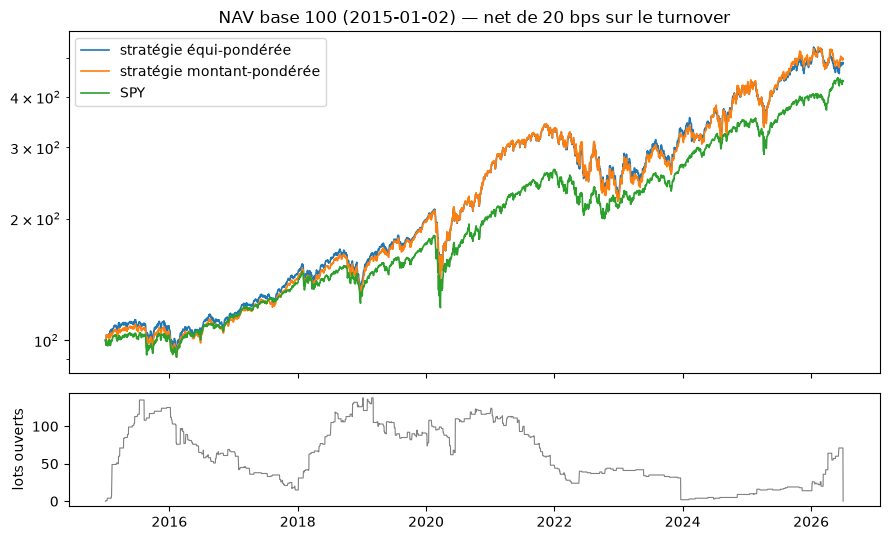

lots ouverts : médiane 57, max 138 | jours sans position : 0%


In [20]:
# Le compte 2015-2026, net de coûts — équi- et montant-pondéré, vs le même argent dans SPY.
import matplotlib.pyplot as plt

DEB = CAL[CAL.searchsorted(pd.Timestamp("2015-01-01"))]
r_spy = spy.pct_change().fillna(0.0)

r_eq, TO_eq, n_lots = portefeuille_poids(bt_ptf)
r_mt, TO_mt, _ = portefeuille_poids(bt_ptf, col_a="a_montant")
r_eq, TO_eq, r_mt, TO_mt = (s.loc[DEB:] for s in (r_eq, TO_eq, r_mt, TO_mt))
rb = r_spy.loc[r_eq.index]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
for r_, lab in [(r_eq, "stratégie équi-pondérée"), (r_mt, "stratégie montant-pondérée"), (rb, "SPY")]:
    ax.plot((1 + r_).cumprod() * 100, label=lab, lw=1.2)
ax.set_yscale("log"); ax.legend()
ax.set_title("NAV base 100 (2015-01-02) — net de 20 bps sur le turnover")
ax2.plot(n_lots.loc[DEB:], lw=0.8, color="grey"); ax2.set_ylabel("lots ouverts")
plt.tight_layout(); plt.show()
print(f"lots ouverts : médiane {int(n_lots.loc[DEB:].median())}, max {int(n_lots.max())} "
      f"| jours sans position : {(n_lots.loc[DEB:] == 0).mean():.0%}")

In [21]:
# Les métriques de compte (mécanique du notebook 05, adaptée). Le t viendra de l'année par année (§7.3).
def stats_ptf(r_, TO_):
    nav = (1 + r_).cumprod(); n = len(r_)
    x = (r_ - r_spy.reindex(r_.index)).dropna()
    r_brut = (1 + r_) / (1 - COST * TO_.reindex(r_.index).fillna(0.0)) - 1
    return {"CAGR": f"{nav.iloc[-1] ** (252 / n) - 1:+.2%}",
            "vol": f"{r_.std() * np.sqrt(252):.1%}",
            "Sharpe": round(r_.mean() / r_.std() * np.sqrt(252), 2),
            "maxDD": f"{(nav / nav.cummax() - 1).min():.0%}",
            "IR vs SPY": round(x.mean() / x.std() * np.sqrt(252), 2) if x.std() > 0 else "—",
            "turnover/an": f"{TO_.reindex(r_.index).fillna(0.0).groupby(r_.index.year).sum().mean():.1f}×",
            "coûts (bps/an)": int(round(((1 + r_brut).prod() ** (252 / n)
                                         - (1 + r_).prod() ** (252 / n)) * 1e4))}

def yearly_excess(r_):
    b_ = r_spy.reindex(r_.index)
    return pd.Series({y: float((1 + r_[r_.index.year == y]).prod() - (1 + b_[b_.index.year == y]).prod())
                      for y in sorted(set(r_.index.year))})

r_dd, TO_dd, _ = portefeuille_poids(
    bt_ptf.drop_duplicates(subset=["bioguide_id", "ticker_yahoo", "disclosure_date"]))
lignes_st = {"équi-pondéré": (r_eq, TO_eq), "montant-pondéré": (r_mt, TO_mt),
             "équi dédupliqué": (r_dd.loc[DEB:], TO_dd.loc[DEB:]),
             "SPY": (rb, pd.Series(0.0, index=rb.index))}
tableau = pd.DataFrame({nom: {**stats_ptf(r_, TO_),
                              "excès/an": "—" if nom == "SPY" else f"{yearly_excess(r_).mean():+.2%}"}
                        for nom, (r_, TO_) in lignes_st.items()}).T
print(tableau.to_string())

                    CAGR    vol Sharpe maxDD IR vs SPY turnover/an coûts (bps/an) excès/an
équi-pondéré     +14.76%  21.7%   0.74  -35%      0.17        7.3×            176   +1.95%
montant-pondéré  +14.98%  22.5%   0.73  -36%      0.19        7.4×            179   +2.33%
équi dédupliqué  +14.54%  21.6%   0.74  -36%      0.16        7.2×            174   +1.43%
SPY              +13.76%  17.6%   0.82  -34%         —        0.0×              0        —


### 7.3 L'année par année — le test qui compte

- Le juge de paix reste celui du §4 : la série des **excès annuels**, ici **composés en NAV** —
$$e_Y \;=\; \prod_{t \in Y}\big(1+r_P^{net}(t)\big) \;-\; \prod_{t \in Y}\big(1+r_{SPY}(t)\big)\,,
\qquad t = \frac{\bar e}{s_e/\sqrt{n}}\,,\quad n = 12$$
- Différence de convention avec la grille du §4 : une année sans nouveau lot n'est plus comptée « 0 » —
  le compte y vit sur ses positions héritées, et s'il était vide il ferait $e_Y = -r_{SPY,Y}$ (être en
  cash a un coût d'opportunité réel). C'est la réalité du produit.
- $n = 12$ observations annuelles (2026 partielle) : l'intervalle de confiance est énorme — on lit $t$
  comme un ordre de grandeur.

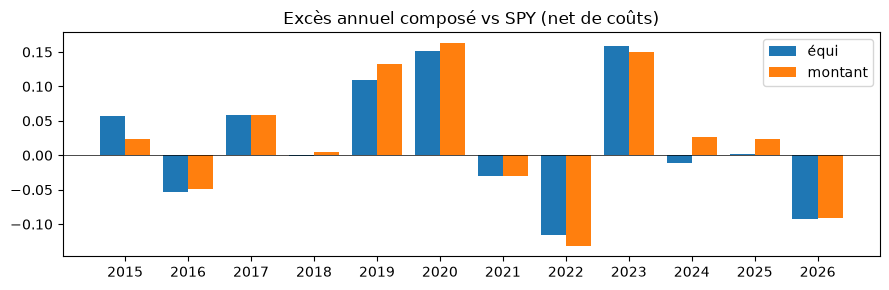

série équi par année : {2015: '+5.7%', 2016: '-5.3%', 2017: '+5.8%', 2018: '-0.0%', 2019: '+11.0%', 2020: '+15.1%', 2021: '-3.0%', 2022: '-11.5%', 2023: '+15.9%', 2024: '-1.1%', 2025: '+0.2%', 2026: '-9.3%'}
équi     excès moyen +1.95%/an | t(n=12) 0.76 | sans 2026 partielle : t 1.14 | années > 0 : 50%
montant  excès moyen +2.33%/an | t(n=12) 0.87 | sans 2026 partielle : t 1.25 | années > 0 : 67%


In [22]:
e_eq, e_mt = yearly_excess(r_eq), yearly_excess(r_mt)
fig, ax = plt.subplots(figsize=(9, 3))
xpos = np.arange(len(e_eq))
ax.bar(xpos - 0.2, e_eq.values, 0.4, label="équi")
ax.bar(xpos + 0.2, e_mt.values, 0.4, label="montant")
ax.set_xticks(xpos); ax.set_xticklabels(e_eq.index)
ax.axhline(0, color="k", lw=0.5); ax.legend()
ax.set_title("Excès annuel composé vs SPY (net de coûts)")
plt.tight_layout(); plt.show()

print("série équi par année :", {int(k): f"{v:+.1%}" for k, v in e_eq.items()})
for nom, e in [("équi", e_eq), ("montant", e_mt)]:
    e11 = e[e.index < 2026]
    print(f"{nom:8s} excès moyen {e.mean():+.2%}/an | t(n={len(e)}) "
          f"{e.mean() / (e.std() / np.sqrt(len(e))):.2f} | sans 2026 partielle : "
          f"t {e11.mean() / (e11.std() / np.sqrt(len(e11))):.2f} | années > 0 : {(e > 0).mean():.0%}")

In [23]:
# V2 ETF en compte : mêmes lots, mêmes dates, l'instrument devient l'ETF sectoriel
# (intersection stricte comme au §6 : lots dont l'excès ETF est calculable).
x_etf, _ = trade_excess_net(bt_ptf["etf_proxy"].to_numpy(), bt_ptf["disclosure_date"].to_numpy(),
                            bt_ptf["sortie_vente"].to_numpy())
sub = bt_ptf[np.isfinite(x_etf)]
lignes_v2 = {}
for nom, ctk in [("V1 actions (mêmes lots)", "ticker_yahoo"), ("V2 ETF sectoriels", "etf_proxy")]:
    r_, TO_, _ = portefeuille_poids(sub, col_tk=ctk)
    r_, TO_ = r_.loc[DEB:], TO_.loc[DEB:]
    lignes_v2[nom] = {**stats_ptf(r_, TO_), "excès/an": f"{yearly_excess(r_).mean():+.2%}"}
print(f"intersection stricte : {len(sub):,}/{len(bt_ptf):,} lots")
print(pd.DataFrame(lignes_v2).T.to_string())

intersection stricte : 991/1,037 lots
                            CAGR    vol Sharpe maxDD IR vs SPY turnover/an coûts (bps/an) excès/an
V1 actions (mêmes lots)  +14.55%  21.7%   0.73  -35%      0.15        7.2×            174   +1.76%
V2 ETF sectoriels        +13.63%  18.7%   0.78  -35%      0.02        4.2×            100   -0.17%


### 7.4 Lecture — la vue portefeuille confirme le §4, et l'affaiblit encore

- **Le +3,11 %/trade du §4 ne survit pas au passage en compte** : excès composé **+1,9 %/an** (équi,
  t 0,76) à **+2,3 %/an** (montant, t 0,87) — moins que la moyenne par trade, et encore moins
  significatif. Les poids temporels, les chevauchements et les coûts sur le turnover font la différence.
- **Le client prend plus de risque que SPY pour ça** : Sharpe **0,74 < 0,82** (SPY), vol 21,7 % vs
  17,6 %, même maxDD (−35 %). IR 0,17 : par unité de risque relatif pris contre SPY, presque rien.
- **Les coûts réels sont lourds** : turnover ≈ 7×/an → ≈ 175 bps/an de drag, dont une bonne part vient
  du rebalancement quotidien de la discipline équi-pondérée elle-même (limite de construction assumée).
- **Le résultat n'est pas un artefact de sizing** : équi-pondéré, montant-pondéré et dédupliqué
  multi-comptes donnent la même image — excès annuel de +1,43 à +2,33 %/an selon la construction,
  t < 1 partout (colonne « excès/an » du tableau ci-dessus).
- **V2 ETF : l'excès disparaît en compte** (−0,2 %/an, IR 0,02) — la dilution du §6, vue en NAV.
- Années creuses de sélection (2023-2025 : 3 à 15 lots) : le compte vit alors surtout sur l'héritage des
  positions laissées courir — la stratégie « vivante » est plus concentrée qu'il n'y paraît.

## 8. Verdict

| Question | Réponse (2014-2026, donnée canonique, net de 40 bps A/R) |
|---|---|
| De l'info dans les trades, au plafond (`transaction_date`) ? | **Non** — achats −0,18 % (1 m) à −0,76 % (6 m) vs SPY, t < −4 |
| Un drift copiable à la publication ? | Trace réelle (+7 bps le 1er mois, t 1,9) mais **6× sous les coûts** |
| La stratégie du brief (top-K Sharpe, sortie vente plafonnée à 12 m) ? | +0,7 à +3,6 %/trade selon config, **t ≤ 1,3 sur les 8 essais** — pas d'alpha démontrable ; le copy-trading non sélectif perd (−0,42 %/trade) |
| Et en compte réel (NAV quotidienne, coûts sur le turnover) ? | Excès composé **+1,9 à +2,3 %/an, t ≤ 0,9** ; **Sharpe 0,74 < SPY 0,82** pour plus de vol (21,7 % vs 17,6 %) ; robuste au sizing (équi / montant / dédup) |
| Les 12 leaders de parti (Wei & Zhou) ? | **Non testable** : ~6 leaders traders, 89 % des trades = une personne en 2025 |
| La V2 ETF sectorielle ? | Dilution par trade (§6) **et** en compte : excès ≈ 0, IR 0,02 — le signal résiduel est spécifique au titre |

**Ce que ça veut dire pour Ramify** :
- Notre résultat réplique le consensus académique (Belmont 2022) et le marché réel (NANC/GOP) : **pas
  d'alpha moyen copiable** dans les trades du Congrès post-STOCK Act. Ce qui reste est une loterie à
  queue droite qu'une sélection ex-ante ne capte pas.
- Un produit « Congrès » se défend comme **bêta thématique transparent** (à la NANC : +2,7 pp/an vs SPY
  depuis 2023 mais −3,8 pp vs QQQ — du style, pas du talent), pas comme une promesse de battre le marché.
- **Pistes restantes non testées ici** (cf. `ETAT_DE_L_ART_STRATEGIES.md`) : juridiction de comité ×
  industrie (+50 bps à l'annonce), trades × jalons législatifs (Li 2025 : +3-5 %), conviction par
  taille (« Best Ideas »). Matière pour une v2 de ce notebook.
- **Risque réglementaire** : le HONEST Act (ban du trading des élus) a passé la commission sénatoriale
  en 2025 — toute mise en production vivrait sous ce risque d'extinction du signal.

**Limites assumées de cette v1** : t simples (fenêtres chevauchantes et lots multi-comptes → t
optimistes — ils ne sont déjà pas significatifs) ; couverture prix 87,8 %, plus trouée en début de
fenêtre (~74 % en 2014) ; construction en poids rebalancée quotidiennement (le drag ≈ 175 bps/an du §7
inclut le rebalancement de la discipline équi-pondérée) ; cash à 0 % ; pas de slippage au-delà des
20 bps ; 10 % des achats récents ont une détention tronquée au 2026-07-02.